# Open-Meteo API with WxData

In this example, we will demonstrate using WxData with the Open-Meteo API by doing the following:

1) Retrieve 50 ECMWF IFS Ensemble Members for 2-Meter Temperature for Chicago, IL for the next 10 days.
2) Create an ensemble spaghetti plot with these members

## Imports

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as md
from wxdata import open_meteo_api_ecmwf

### Retrieve ECMWF IFS Ensemble Data via Open-Meteo API

In [2]:
df = open_meteo_api_ecmwf.ifs_hourly_ensemble_point_forecast(41.87, 
                                                             -87.63, 
                                                             days=10,
                                                             variables=['temperature_2m'])

In [3]:
df

,time,temperature_2m,temperature_2m_member01,temperature_2m_member02,temperature_2m_member03,temperature_2m_member04,temperature_2m_member05,temperature_2m_member06,temperature_2m_member07,temperature_2m_member08,...,temperature_2m_member41,temperature_2m_member42,temperature_2m_member43,temperature_2m_member44,temperature_2m_member45,temperature_2m_member46,temperature_2m_member47,temperature_2m_member48,temperature_2m_member49,temperature_2m_member50
0,2026-07-20 00:00:00,74.5,72.9,75.6,73.3,76.8,73.6,74.6,75.3,75.8,...,75.1,76.2,73.1,75.6,75.4,75.6,73.6,76.6,75.8,75.4
1,2026-07-20 01:00:00,73.1,71.5,74.1,72.0,75.2,72.4,73.1,73.9,74.1,...,73.5,74.7,71.7,74.2,73.8,74.2,72.3,75.2,74.2,74.0
2,2026-07-20 02:00:00,71.4,70.0,72.5,70.6,73.6,71.2,71.5,72.4,72.1,...,71.7,73.0,70.2,72.6,72.0,72.6,70.8,74.0,72.6,72.5
3,2026-07-20 03:00:00,70.0,68.7,71.3,69.5,72.3,70.2,70.1,71.1,70.6,...,70.2,71.5,69.0,71.4,70.6,71.4,69.7,72.8,71.3,71.3
4,2026-07-20 04:00:00,69.1,67.8,70.5,68.8,71.5,69.7,69.4,70.2,70.1,...,69.1,70.7,68.4,70.6,69.7,70.5,68.8,71.9,70.6,70.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2026-07-29 19:00:00,71.0,83.5,102.5,74.6,83.5,78.8,73.7,80.2,76.0,...,75.2,92.2,99.9,75.7,87.1,79.7,72.4,72.6,82.0,78.3
236,2026-07-29 20:00:00,70.9,83.2,101.2,74.4,83.2,78.3,73.2,79.8,76.1,...,75.4,92.1,99.4,75.7,86.7,79.6,71.5,72.0,81.7,78.2
237,2026-07-29 21:00:00,70.7,82.4,99.5,74.0,82.6,77.6,72.4,79.3,76.0,...,75.3,91.5,98.5,75.3,85.9,79.2,70.3,71.4,81.1,77.8
238,2026-07-29 22:00:00,70.4,81.5,97.6,73.4,82.0,76.7,71.6,78.7,75.9,...,75.1,90.6,97.4,74.8,84.9,78.7,69.0,70.6,80.2,77.3


### Create Our Graphic

In [4]:
# Create a list of our ensemble members
members = []
for i in range(1, 51, 1):
    if i < 10:
        member = f"temperature_2m_member0{i}"
    else:
        member = f"temperature_2m_member{i}"
    members.append(member)

Text(0, 0, 'Plot Created by Eric J. Drewitz - Powered By WxData')

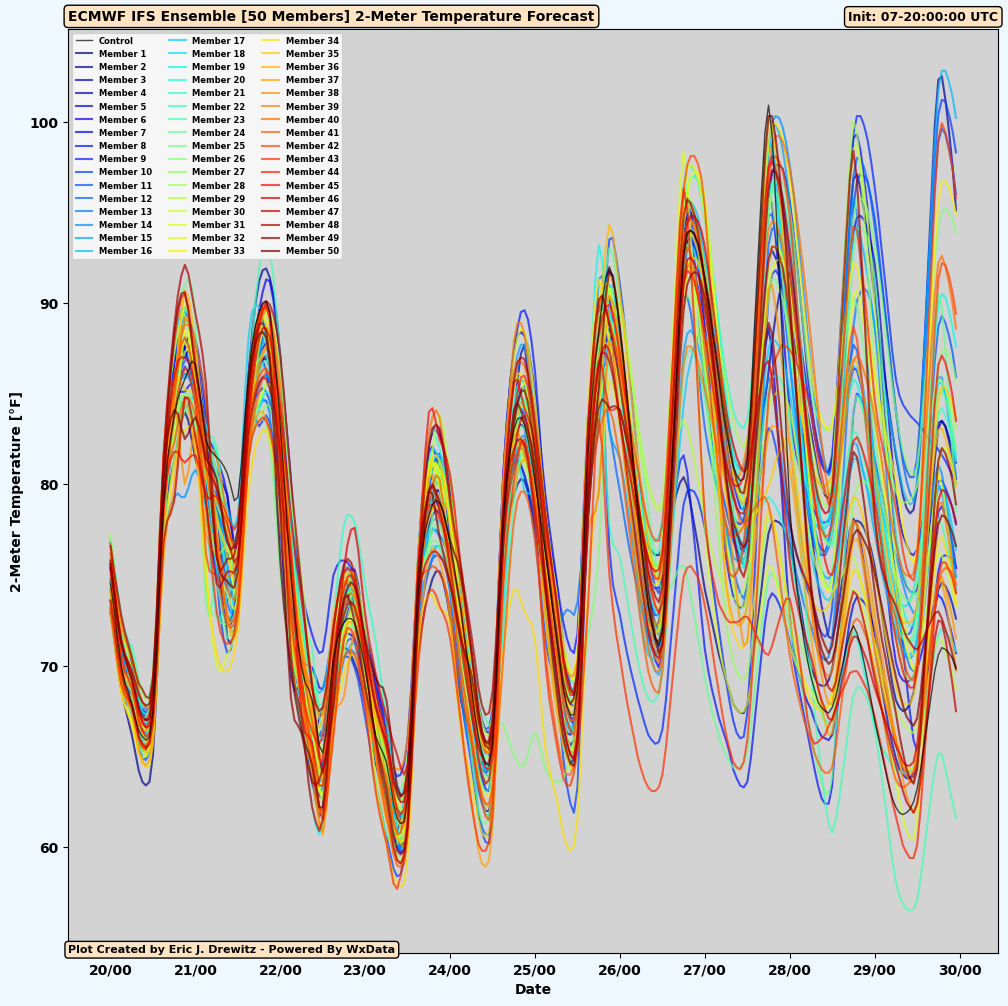

In [5]:
# Make all the tick marks on the plot bold
mpl.rcParams['font.weight'] = 'bold'

# Create our text box
text_box = dict(boxstyle='round', 
                            facecolor='bisque', 
                            alpha=1)

# Create our figure with a 12x12 size
fig = plt.figure(figsize=(12,12))

# Set the facecolor of our figure to a light blue
fig.set_facecolor('aliceblue')

# Create our subplot axis
ax = fig.add_subplot(1,1,1)

# Set the facecolor to our subplot to a light grey
ax.set_facecolor('lightgrey')

# Label our x and y axes
ax.set_ylabel("2-Meter Temperature [°F]", fontweight='bold')
ax.set_xlabel("Date", fontweight='bold')

# Set our x-axis labels using the '%d/%H' datetime format
ax.xaxis.set_major_formatter(md.DateFormatter('%d/%H'))
ax.xaxis.set_major_locator(md.DayLocator(interval=1))

# Create our plot title
plt.title(f'ECMWF IFS Ensemble [50 Members] 2-Meter Temperature Forecast', 
          fontsize=10, 
          fontweight='bold', 
          loc='left',
         bbox=text_box)

# Add the model initialization to the plot title
plt.title(f'Init: {df['time'].iloc[0].strftime('%m-%d:%H:00 UTC')}', 
          fontsize=9, 
          fontweight='bold', 
          loc='right',
         bbox=text_box)

# Choose our colormap
cmap = plt.colormaps['jet']

# Plot our control run
ax.plot(df['time'], df['temperature_2m'], color='black', alpha=0.7, linewidth=1, label=f'Control', zorder=52)

# Plot our ensemble list looping through our list of members
for i in range(0, len(members), 1):
    color_fraction = i / (len(members) - 1)
    line_color = cmap(color_fraction)
    ax.plot(df['time'], df[members[i]], color=line_color, alpha=0.7, label=f'Member {i+1}')

# Create our plot legend
ax.legend(loc='upper left', ncol=3, prop={'size': 6})

# Add our signature
ax.text(0, 0, f"Plot Created by Eric J. Drewitz - Powered By WxData", fontsize=8, fontweight='bold', transform=ax.transAxes, bbox=text_box, zorder=5)